# Actividad 1. Segmentación de clientes mediante Aprendizaje No Supervisado 

## Introducción

### Objetivos

Aplicar técnicas de aprendizaje no supervisado para segmentar clientes en función de sus características demográficas y de consumo, con el fin de identificar patrones ocultos y grupos homogéneos que puedan orientar decisiones de marketing y estrategias comerciales. 

### Conjunto de datos:
Este dataset contiene 200 registros de clientes con variables como edad, ingresos anuales y puntuación de gasto.  
Mall Customers Dataset (Kaggle): [https://www.kaggle.com/datasets/shwetabh123/mall-customers](https://www.kaggle.com/datasets/shwetabh123/mall-customers)

## 1. Análisis exploratorio del conjunto de datos
- Carga del dataset. 
- Análisis descriptivo de las variables. 
- Identificación de posibles valores atípicos.

### 1.1. Imports

In [20]:
# imports:

import kagglehub
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### 1.2. Estilos


In [30]:
FONDO   = "#11151c"
TEXTO   = "#e6edf3"
ACENTO  = "#4fd1c5"
REJILLA = "#2a313c"
PALETA  = ["#4fd1c5", "#f6c177", "#c191f2", "#7aa2f7", "#f7768e", "#9ece6a"]

sns.set_theme(style="darkgrid")
mpl.rcParams.update({
    # Fondos
    "figure.facecolor":  FONDO,
    "axes.facecolor":    FONDO,
    "savefig.facecolor": FONDO,
    # Textos y ejes
    "text.color":        TEXTO,
    "axes.labelcolor":   TEXTO,
    "xtick.color":       TEXTO,
    "ytick.color":       TEXTO,
    "axes.edgecolor":    REJILLA,
    "grid.color":        REJILLA,
    # Títulos: turquesa, en negrita y alineados a la izquierda
    "axes.titlecolor":    ACENTO,
    "axes.titlesize":     15,
    "axes.titleweight":   "bold",
    "axes.titlelocation": "left",
    "axes.titlepad":      12,
    # Tamaños y leyenda por defecto
    "figure.figsize": (6, 4),
    "font.size":      11,
    "legend.frameon": False,
})
sns.set_palette(PALETA)

print("Estilos aplicados. Paleta:", PALETA)


Estilos aplicados. Paleta: ['#4fd1c5', '#f6c177', '#c191f2', '#7aa2f7', '#f7768e', '#9ece6a']


In [31]:
# Descarga el dataset de Kaggle y carga el CSV en un DataFrame de pandas
CSV_PATH = kagglehub.dataset_download("shwetabh123/mall-customers") + "/Mall_Customers.csv"

df = pd.read_csv(CSV_PATH)

display(df.head())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1.3. Análisis general


In [32]:
# Información general del dataset
print(f"- Dimensiones del dataset (shape): {df.shape}\n")
print("- Información de las variables:")
df.info()

- Dimensiones del dataset (shape): (200, 5)

- Información de las variables:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


- Vemos que no tenemos nulls. 
- "Genre" es de tipo "object". Lo cambiaremos a tipo "category" para una mejor eficiencia y coherencia.

In [33]:
df['Genre'] = df['Genre'].astype('category')

#### Análisis de las variables no numéricas
- Únicamente Genre (Male y Female)

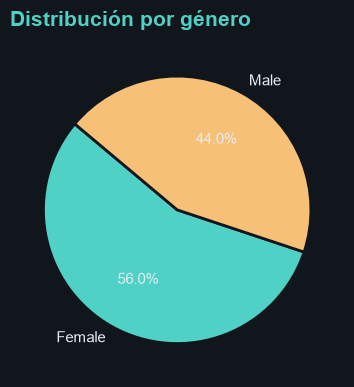

Genre
Female    112
Male       88
Name: count, dtype: int64


In [34]:
# Análisis de la variable categórica (Genre): Male / Female
conteo_genero = df["Genre"].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=PALETA[:len(conteo_genero)],
    textprops={"color": TEXTO},
    wedgeprops={"edgecolor": FONDO, "linewidth": 2},
)
plt.title("Distribución por género")
plt.tight_layout()
plt.show()

print(conteo_genero)


#### Análisis de las variables numéricas


In [35]:
# Análisis de las variables numéricas
if df['CustomerID'].unique().size == df.shape[0]:
    print("* 'CustomerID' es un identificador único. Será excluido del análisis.")
else:
    print("* 'CustomerID' NO es un identificador único.\n")

# Crear una copia del dataset sin 'CustomerID'
print("\n    - Estadísticas descriptivas de las variables numéricas:")
print(df.describe())

* 'CustomerID' es un identificador único. Será excluido del análisis.

    - Estadísticas descriptivas de las variables numéricas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


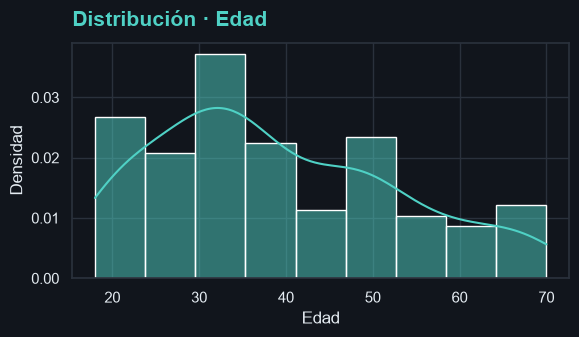

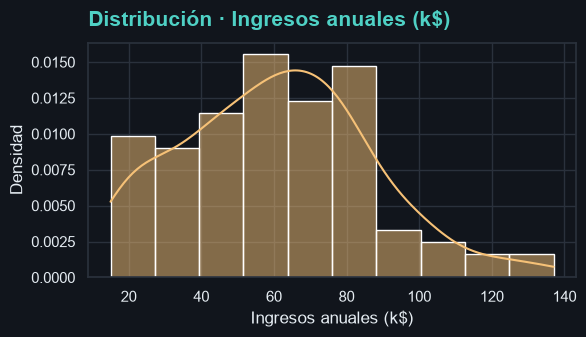

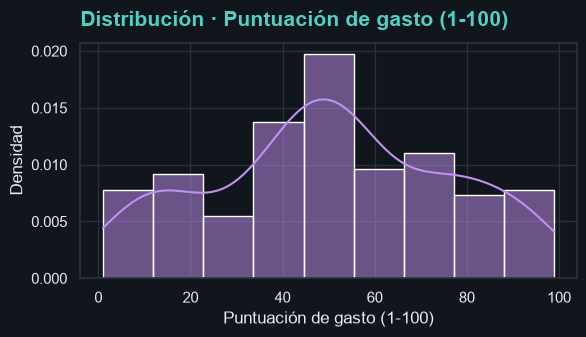

In [39]:
# Distribución de cada variable numérica
variables_num = [
    ("Age", "Edad"),
    ("Annual Income (k$)", "Ingresos anuales (k$)"),
    ("Spending Score (1-100)", "Puntuación de gasto (1-100)"),
]

for (columna, etiqueta), color in zip(variables_num, PALETA):
    plt.figure(figsize=(6, 3.5))
    sns.histplot(df[columna], kde=True, color=color, stat="density")
    plt.title(f"Distribución · {etiqueta}")
    plt.xlabel(etiqueta)
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()


#### Valores atípicos

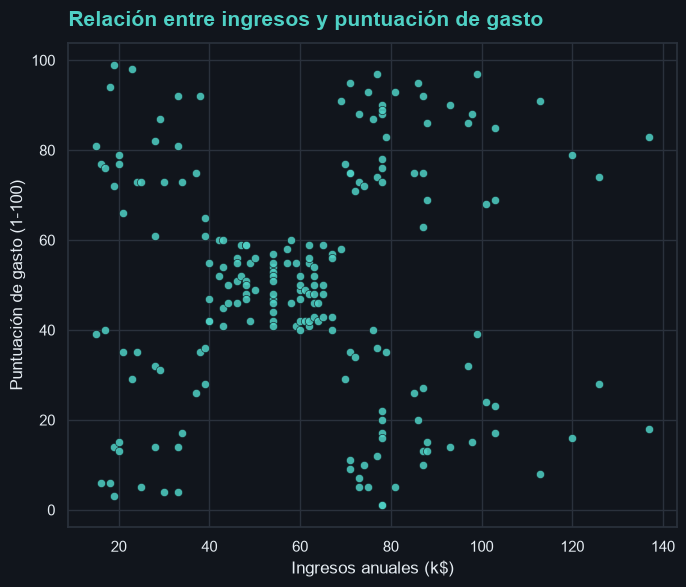

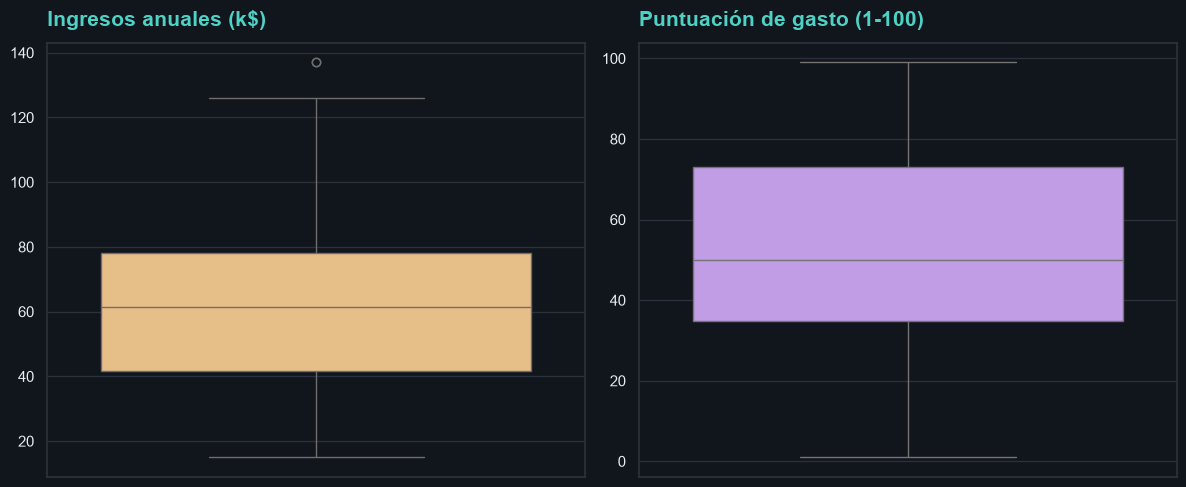

In [37]:
# Búsqueda de posibles valores atípicos
# 1) Relación entre ingresos y puntuación de gasto
plt.figure(figsize=(7, 6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    s=35,
    alpha=0.85,
    color=PALETA[0],
    edgecolor=FONDO,
    linewidth=0.5,
)
plt.xlabel("Ingresos anuales (k$)")
plt.ylabel("Puntuación de gasto (1-100)")
plt.title("Relación entre ingresos y puntuación de gasto")
plt.tight_layout()
plt.show()

# 2) Diagramas de caja
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y="Annual Income (k$)", color=PALETA[1])
plt.title("Ingresos anuales (k$)")
plt.ylabel("")
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y="Spending Score (1-100)", color=PALETA[2])
plt.title("Puntuación de gasto (1-100)")
plt.ylabel("")
plt.tight_layout()
plt.show()


No parece que haya valores atípicos.

### 2. Preprocesamiento 
- Limpieza de datos. 
- Escalado de variables numéricas. 
- Selección de variables relevantes para el clustering. 

In [38]:
# OBJETIVO: dejar las 3 variables con media=0 y desviación típica=1, para que pesen por igual.

# --- Estado previo: escalas muy diferentes ---
df_scaled = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
print("ANTES del escalado:")
print(df_scaled.describe().loc[["mean", "std", "min", "max"]].round(2))

# --- Aplicar StandardScaler ---
scaler = StandardScaler()
df_scaled_fit = scaler.fit_transform(df_scaled)   # fit aprende μ y σ, transform las aplica

# Reconstruir DataFrame (fit_transform devuelve un array sin nombres)
df_scaled_fit = pd.DataFrame(df_scaled_fit,
                             columns=["Age", "Annual Income (k$)", "Spending Score (1-100)"])

# --- Estado posterior: todas centradas y normalizadas ---
print("\nDESPUÉS del escalado:")
print(df_scaled_fit.describe().loc[["mean", "std", "min", "max"]].round(2))

df_scaled_fit.head()

ANTES del escalado:
        Age  Annual Income (k$)  Spending Score (1-100)
mean  38.85               60.56                   50.20
std   13.97               26.26                   25.82
min   18.00               15.00                    1.00
max   70.00              137.00                   99.00

DESPUÉS del escalado:
       Age  Annual Income (k$)  Spending Score (1-100)
mean -0.00               -0.00                   -0.00
std   1.00                1.00                    1.00
min  -1.50               -1.74                   -1.91
max   2.24                2.92                    1.89


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980



### 3. Aplicación de técnicas de clustering 
- Entrena al menos dos métodos distintos (por ejemplo: K-Means, DBSCAN, Agglomerative Clustering). 
- Determina el número óptimo de clusters usando métodos como Elbow Method o Silhouette Score. 

### 4. Visualización y análisis de los resultados 
- Representación gráfica de los clusters (2D/3D). 
- Interpretación de las características principales de cada grupo. 
- Comparación de los resultados obtenidos con cada método. 

### 5. Conclusiones y posibles aplicaciones 
- Discute cómo podrían emplearse los resultados en un contexto real (segmentación de mercado, campañas personalizadas, etc.). 
- Identifica limitaciones y posibles mejoras. 